# 🎓 Student Segmentation & Personalised Course Recommendation System — EduPro

**A beginner-friendly, line-by-line guided notebook**

This notebook is written so that someone who is *new to data analysis* can follow every single step — not just run the code, but understand **why** each line exists and **what it means for the business (EduPro)**.

---

### 📌 Business Problem

EduPro (an online learning platform) currently has three problems:

1. **One-size-fits-all recommendations** — every learner sees roughly the same course suggestions, regardless of who they are or what they've bought before.
2. **Limited understanding of learner behaviour** — EduPro doesn't know *which kinds* of learners it has (e.g., casual browsers vs. serious upskillers vs. budget-conscious students).
3. **No structured segmentation framework** — there's no repeatable, data-driven way to group learners so that marketing, content, and recommendations can be tailored to each group.

**Business consequence:** learners struggle to find content relevant to them → they disengage → EduPro loses retention and revenue opportunities.

---

### 🎯 What this notebook does

We will follow this exact roadmap:

| Step | What we do | Why it matters to the business |
|---|---|---|
| 1 | Load & explore the raw data | Understand what information we actually have |
| 2 | Aggregate transactions to the **learner level** | One row = one learner's full behaviour profile |
| 3 | Preprocess (scale + encode) | Make the data "clustering-ready" |
| 4 | **K-Means clustering** (+ Elbow & Silhouette) | Find natural learner segments |
| 5 | **Hierarchical clustering** | Validate that the segments are real, not a fluke |
| 6 | Profile each cluster in business language | Turn cluster numbers into "personas" marketing can use |
| 7 | Build a **personalised recommendation engine** | Recommend courses using content similarity, similar-learner behaviour, in-cluster popularity, and rating-weighting |

Every code cell below is preceded by a markdown cell that explains, **line by line**, what the code does.


## Step 1 — Import the Tools (Libraries) We Need

Think of libraries as "toolboxes". Python itself is quite basic, so we import specialised toolboxes for data handling, math, and charts.

- **`pandas`** → the toolbox for working with tables (rows & columns), just like Excel but programmable. We nickname it `pd`.
- **`numpy`** → the toolbox for numerical/mathematical operations (arrays, averages, etc.). Nicknamed `np`.
- **`matplotlib.pyplot`** and **`seaborn`** → toolboxes for drawing charts (bar charts, line charts, heatmaps).
- **`sklearn` (scikit-learn)** → the toolbox that contains our machine learning algorithms: scaling, encoding, clustering (K-Means, Hierarchical), and similarity calculations.
- **`scipy.cluster.hierarchy`** → used specifically to draw the *dendrogram* (tree diagram) for hierarchical clustering.
- **`warnings`** → we use this only to hide harmless technical warning messages so the notebook stays clean for beginners.


In [1]:
# --- Core data-handling libraries ---
import pandas as pd            # for tables (DataFrames) - our main way of holding data
import numpy as np             # for numerical operations (averages, arrays, random numbers)

# --- Visualisation libraries ---
import matplotlib.pyplot as plt   # for drawing charts
import seaborn as sns             # for nicer-looking statistical charts
sns.set_style("whitegrid")        # a clean chart background style

# --- Machine Learning libraries (from scikit-learn) ---
from sklearn.preprocessing import StandardScaler, OneHotEncoder   # for scaling & encoding
from sklearn.cluster import KMeans, AgglomerativeClustering       # our two clustering algorithms
from sklearn.metrics import silhouette_score                      # to judge cluster quality
from sklearn.metrics.pairwise import cosine_similarity            # to measure "similarity" between courses/learners
from scipy.cluster.hierarchy import dendrogram, linkage           # to draw the hierarchical "tree"

# --- Housekeeping ---
import warnings
warnings.filterwarnings("ignore")   # hide harmless warning messages so output stays clean

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## Step 2 — Load the Three Datasets

EduPro's data lives in **three separate sheets/tables**:

| Sheet | Key columns | What it represents |
|---|---|---|
| **Users** | `UserID`, `Age`, `Gender` | Who the learner is (demographics) |
| **Courses** | `CourseID`, `CourseCategory`, `CourseType`, `Course Level`, `CourseRating` | What is being sold/taught |
| **Transactions** | `UserID`, `CourseID`, `TransactionDate`, `Amount` | What each learner actually bought, when, and for how much |

**Business logic:** Transactions is the "glue" table — it links a *Learner* (Users) to a *Course* (Courses) through a purchase event. Without joining these three tables, we can't answer questions like *"What kind of courses does a 25-year-old learner usually buy, and how much do they spend?"*

### 📂 How to load your own files
If you have `users.csv`, `courses.csv`, and `transactions.csv` (or an Excel file with three sheets), place them in the same folder as this notebook and un-comment the loading lines below.

For this notebook to **run end-to-end without your files**, we first generate a small **synthetic (fake but realistic) dataset** that matches your exact schema. Replace this block with your real file-loading code when you have your actual EduPro export.


In [2]:
# ------------------------------------------------------------------
# OPTION A: Load your REAL EduPro data (uncomment and edit the paths)
# ------------------------------------------------------------------
# users_df        = pd.read_csv("users.csv")
# courses_df      = pd.read_csv("courses.csv")
# transactions_df = pd.read_csv("transactions.csv")

# If your data is in one Excel workbook with 3 sheets instead, use:
# users_df        = pd.read_excel("EduPro_Data.xlsx", sheet_name="Users")
# courses_df      = pd.read_excel("EduPro_Data.xlsx", sheet_name="Courses")
# transactions_df = pd.read_excel("EduPro_Data.xlsx", sheet_name="Transactions")

# ------------------------------------------------------------------
# OPTION B: Synthetic sample data (so this notebook runs right now)
# Delete/skip this block once you plug in your real files above.
# ------------------------------------------------------------------
np.random.seed(42)   # makes the "random" data reproducible every time we run this cell

# --- Users sheet ---
n_users = 300
users_df = pd.DataFrame({
    "UserID": [f"U{i:04d}" for i in range(1, n_users + 1)],
    "Age": np.random.randint(16, 55, size=n_users),
    "Gender": np.random.choice(["Male", "Female", "Other"], size=n_users, p=[0.48, 0.48, 0.04])
})

# --- Courses sheet ---
categories = ["Data Science", "Web Development", "Marketing", "Design", "Business", "Finance", "AI/ML"]
course_types = ["Video", "Live Cohort", "Text-based"]
levels = ["Beginner", "Intermediate", "Advanced"]

n_courses = 60
courses_df = pd.DataFrame({
    "CourseID": [f"C{i:03d}" for i in range(1, n_courses + 1)],
    "CourseCategory": np.random.choice(categories, size=n_courses),
    "CourseType": np.random.choice(course_types, size=n_courses),
    "Course Level": np.random.choice(levels, size=n_courses),
    "CourseRating": np.round(np.random.uniform(2.5, 5.0, size=n_courses), 1)
})

# --- Transactions sheet ---
n_transactions = 1800
transactions_df = pd.DataFrame({
    "UserID": np.random.choice(users_df["UserID"], size=n_transactions),
    "CourseID": np.random.choice(courses_df["CourseID"], size=n_transactions),
    "TransactionDate": pd.to_datetime("2024-01-01") + pd.to_timedelta(
        np.random.randint(0, 500, size=n_transactions), unit="D"),
    "Amount": np.round(np.random.uniform(300, 5000, size=n_transactions), 2)
})

print("Users shape:", users_df.shape)
print("Courses shape:", courses_df.shape)
print("Transactions shape:", transactions_df.shape)


Users shape: (300, 3)
Courses shape: (60, 5)
Transactions shape: (1800, 4)


**How to read `.shape`:** it returns `(rows, columns)`. For example, `Transactions shape: (1800, 4)` means 1,800 purchase records, each described by 4 pieces of information (`UserID`, `CourseID`, `TransactionDate`, `Amount`).


## Step 3 — First Look at the Data (Exploratory Check)

Before building anything, we always **inspect** the raw data. This is like checking your ingredients before cooking — you want to know if anything is missing, duplicated, or looks wrong.

- **`.head()`** shows the first 5 rows so we can visually sanity-check the columns.
- **`.info()`** shows column names, data types (numbers vs text vs dates), and whether there are missing values.
- **`.isnull().sum()`** counts missing values per column — critical, because missing `Amount` or `UserID` values could break our later calculations.


In [3]:
print("----- USERS -----")
display(users_df.head())
users_df.info()
print("\nMissing values in Users:\n", users_df.isnull().sum())


----- USERS -----


,UserID,Age,Gender
0,U0001,54,Male
1,U0002,44,Male
2,U0003,30,Female
3,U0004,23,Female
4,U0005,36,Female


<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   UserID  300 non-null    str  
 1   Age     300 non-null    int32
 2   Gender  300 non-null    str  
dtypes: int32(1), str(2)
memory usage: 6.0 KB

Missing values in Users:
 UserID    0
Age       0
Gender    0
dtype: int64


In [4]:
print("----- COURSES -----")
display(courses_df.head())
courses_df.info()
print("\nMissing values in Courses:\n", courses_df.isnull().sum())


----- COURSES -----


,CourseID,CourseCategory,CourseType,Course Level,CourseRating
0,C001,Business,Text-based,Advanced,4.8
1,C002,Finance,Text-based,Intermediate,2.5
2,C003,Finance,Video,Intermediate,3.1
3,C004,Marketing,Text-based,Beginner,3.4
4,C005,Data Science,Text-based,Intermediate,3.7


<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CourseID        60 non-null     str    
 1   CourseCategory  60 non-null     str    
 2   CourseType      60 non-null     str    
 3   Course Level    60 non-null     str    
 4   CourseRating    60 non-null     float64
dtypes: float64(1), str(4)
memory usage: 2.5 KB

Missing values in Courses:
 CourseID          0
CourseCategory    0
CourseType        0
Course Level      0
CourseRating      0
dtype: int64


In [5]:
print("----- TRANSACTIONS -----")
display(transactions_df.head())
transactions_df.info()
print("\nMissing values in Transactions:\n", transactions_df.isnull().sum())


----- TRANSACTIONS -----


,UserID,CourseID,TransactionDate,Amount
0,U0001,C027,2025-02-02,4800.87
1,U0296,C008,2025-01-16,2959.00
2,U0060,C019,2025-02-15,2717.97
3,U0267,C060,2024-05-31,699.77
4,U0229,C042,2024-03-12,2879.70


<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   UserID           1800 non-null   str           
 1   CourseID         1800 non-null   str           
 2   TransactionDate  1800 non-null   datetime64[us]
 3   Amount           1800 non-null   float64       
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 56.4 KB

Missing values in Transactions:
 UserID             0
CourseID           0
TransactionDate    0
Amount             0
dtype: int64


### 🧹 Basic Cleaning

Real-world data almost always has issues. Here we:
1. Drop exact duplicate rows (the same transaction recorded twice).
2. Drop rows where key IDs are missing (a transaction with no `UserID` is useless — we can't attach it to a learner).
3. Make sure `TransactionDate` is treated as an actual date (not plain text), so we can later calculate "days since last purchase".


In [6]:
# 1. Remove exact duplicate transaction rows
before = len(transactions_df)
transactions_df = transactions_df.drop_duplicates()
print(f"Removed {before - len(transactions_df)} duplicate transaction rows.")

# 2. Drop rows missing the essential keys
transactions_df = transactions_df.dropna(subset=["UserID", "CourseID", "Amount"])

# 3. Ensure TransactionDate is a proper datetime column
transactions_df["TransactionDate"] = pd.to_datetime(transactions_df["TransactionDate"])

print("Cleaned transactions shape:", transactions_df.shape)


Removed 0 duplicate transaction rows.
Cleaned transactions shape: (1800, 4)


## Step 4 — Learner-Level Aggregation

**Business idea:** Right now, our `Transactions` table has *one row per purchase*. But to segment **learners**, we need *one row per learner* that summarises everything they've done.

This is the single most important transformation in the whole project — it turns raw transaction logs into a **learner profile**.

### 4.1 — Join the three tables together
We first **merge** (join) `Transactions` with `Courses` (to know what category/level/rating each purchased course had) and with `Users` (to know the learner's age/gender).

- `pd.merge(left, right, on="column", how="left")` works like a VLOOKUP in Excel: for every row in `left`, it finds the matching row in `right` using the shared column, and pastes the extra columns alongside.
- `how="left"` means: keep every transaction, and only bring in matching course/user info (don't lose transactions even if a lookup fails).


In [7]:
# Merge transactions with course details (adds CourseCategory, CourseType, Course Level, CourseRating)
merged_df = transactions_df.merge(courses_df, on="CourseID", how="left")

# Merge the result with user details (adds Age, Gender)
merged_df = merged_df.merge(users_df, on="UserID", how="left")

display(merged_df.head())
print("Merged dataset shape:", merged_df.shape)


,UserID,CourseID,TransactionDate,Amount,CourseCategory,CourseType,Course Level,CourseRating,Age,Gender
0,U0001,C027,2025-02-02,4800.87,Marketing,Video,Advanced,3.0,54,Male
1,U0296,C008,2025-01-16,2959.00,AI/ML,Live Cohort,Advanced,4.5,48,Female
2,U0060,C019,2025-02-15,2717.97,Design,Video,Intermediate,4.9,51,Male
3,U0267,C060,2024-05-31,699.77,Marketing,Live Cohort,Beginner,3.4,37,Male
4,U0229,C042,2024-03-12,2879.70,Business,Video,Intermediate,3.9,47,Female


Merged dataset shape: (1800, 10)


### 4.2 — Aggregate to one row per `UserID`

Now we use **`groupby("UserID")`** — this is like Excel's PivotTable "Group By" — followed by **`.agg()`**, which tells pandas exactly how to summarise each column for every learner.

Business-meaningful features we create per learner:

| New feature | How it's calculated | Business meaning |
|---|---|---|
| `TotalCourses` | count of transactions | How active/engaged the learner is |
| `TotalSpend` | sum of `Amount` | Learner's overall monetary value |
| `AvgSpend` | mean of `Amount` | Typical price point the learner buys at (budget vs premium) |
| `AvgCourseRating` | mean of `CourseRating` for courses bought | Does the learner favour highly-rated (quality) courses? |
| `FavouriteCategory` | most frequent `CourseCategory` | The learner's dominant subject interest |
| `FavouriteLevel` | most frequent `Course Level` | Are they a beginner, intermediate, or advanced learner? |
| `Recency` | days since their most recent purchase | How "warm" or "cold" (at risk of churn) the learner is |
| `Age`, `Gender` | taken directly from Users | Demographic context |


In [8]:
# A tiny helper function: returns the most frequently occurring value in a column
# (used for "favourite category" / "favourite level" -> think of it as a mini-mode calculation)
def most_common(series):
    return series.mode()[0] if not series.mode().empty else np.nan

# Reference date = one day after the latest transaction in the whole dataset
# We use this to calculate "how many days ago did this learner last buy something?"
reference_date = merged_df["TransactionDate"].max() + pd.Timedelta(days=1)

learner_df = merged_df.groupby("UserID").agg(
    TotalCourses      = ("CourseID", "count"),                 # how many courses purchased
    TotalSpend        = ("Amount", "sum"),                     # total money spent
    AvgSpend          = ("Amount", "mean"),                    # average price point
    AvgCourseRating   = ("CourseRating", "mean"),               # average quality of courses bought
    FavouriteCategory = ("CourseCategory", most_common),        # most-bought subject
    FavouriteLevel    = ("Course Level", most_common),          # most-bought difficulty level
    LastPurchaseDate  = ("TransactionDate", "max"),              # most recent purchase date
).reset_index()

# Recency = days since the learner's last purchase (lower = more recently active)
learner_df["Recency"] = (reference_date - learner_df["LastPurchaseDate"]).dt.days

# Bring back demographic info (Age, Gender) by merging with Users
learner_df = learner_df.merge(users_df, on="UserID", how="left")

# Round numeric columns for readability
learner_df["TotalSpend"]      = learner_df["TotalSpend"].round(2)
learner_df["AvgSpend"]        = learner_df["AvgSpend"].round(2)
learner_df["AvgCourseRating"] = learner_df["AvgCourseRating"].round(2)

display(learner_df.head())
print("\nOne row per learner — shape:", learner_df.shape)


,UserID,TotalCourses,TotalSpend,AvgSpend,AvgCourseRating,FavouriteCategory,FavouriteLevel,LastPurchaseDate,Recency,Age,Gender
0,U0001,6,15358.70,2559.78,3.52,Business,Advanced,2025-02-23,81,54,Male
1,U0002,6,11564.88,1927.48,3.90,Marketing,Advanced,2024-10-14,213,44,Male
2,U0003,8,26596.42,3324.55,3.88,Data Science,Advanced,2025-04-04,41,30,Female
3,U0004,6,14308.04,2384.67,4.10,Business,Beginner,2025-02-08,96,23,Female
4,U0005,8,21642.10,2705.26,3.14,AI/ML,Advanced,2025-04-25,20,36,Female



One row per learner — shape: (298, 11)


✅ **Checkpoint:** `learner_df` now has **one row per unique learner**, describing *who they are* (Age, Gender) and *how they behave* (spend, frequency, favourite category/level, recency). This is exactly the "learner profile" our methodology calls for.

We also filter out learners with **very sparse activity** (e.g., only counted once but with unreliable signal) — the brief calls this "reducing noise from sparse enrolments". Here we keep learners with at least 1 purchase (already guaranteed since we grouped from transactions), but you can raise this threshold (e.g., `>= 2` purchases) if your real dataset is large and noisy.


In [9]:
# Optional noise-reduction: keep only learners with at least 1 purchase (already true by construction).
# If you want stricter noise reduction, uncomment the line below to require at least 2 purchases:
# learner_df = learner_df[learner_df["TotalCourses"] >= 2].reset_index(drop=True)

print("Learner profile table ready with", learner_df.shape[0], "learners and", learner_df.shape[1], "features.")


Learner profile table ready with 298 learners and 11 features.


## Step 5 — Data Preprocessing (Getting Ready for Clustering)

Clustering algorithms like K-Means work with **pure numbers** and are sensitive to **scale**. Two problems to fix:

1. **Different units/scales**: `TotalSpend` might range 0–20,000 while `AvgCourseRating` ranges 1–5. Without scaling, K-Means would think "spend" is far more important simply because its numbers are bigger — that's misleading.
2. **Text categories**: `FavouriteCategory` (e.g., "Data Science") and `FavouriteLevel` (e.g., "Beginner") are text, but K-Means needs numbers.

### 5.1 — Encode categorical variables
We use **One-Hot Encoding**: each category becomes its own 0/1 column. E.g., `FavouriteCategory_DataScience` = 1 if that learner's favourite category is Data Science, else 0.

- `pd.get_dummies()` is a quick pandas way to do one-hot encoding.
- `drop_first=True` drops one category per column to avoid redundant ("dummy trap") columns — a standard best practice.

### 5.2 — Scale numerical variables
We use **`StandardScaler`**, which converts each numeric column to have **mean = 0** and **standard deviation = 1**. This puts every feature on the same footing so no single feature dominates just because of its raw magnitude.


In [10]:
# Select the numeric behavioural/demographic features we'll cluster on
numeric_features = ["Age", "TotalCourses", "TotalSpend", "AvgSpend", "AvgCourseRating", "Recency"]

# Select the categorical features that describe learner preference
categorical_features = ["Gender", "FavouriteCategory", "FavouriteLevel"]

# --- One-hot encode the categorical columns ---
encoded_categoricals = pd.get_dummies(learner_df[categorical_features], drop_first=True)

# --- Scale the numeric columns ---
scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(learner_df[numeric_features])
scaled_numeric_df = pd.DataFrame(scaled_numeric, columns=numeric_features)

# --- Combine scaled numeric + encoded categorical into the final clustering dataset ---
cluster_input_df = pd.concat(
    [scaled_numeric_df.reset_index(drop=True), encoded_categoricals.reset_index(drop=True)],
    axis=1
)

display(cluster_input_df.head())
print("Final feature matrix used for clustering — shape:", cluster_input_df.shape)


,Age,TotalCourses,TotalSpend,AvgSpend,AvgCourseRating,Recency,Gender_Male,Gender_Other,FavouriteCategory_Business,FavouriteCategory_Data Science,FavouriteCategory_Design,FavouriteCategory_Finance,FavouriteCategory_Marketing,FavouriteCategory_Web Development,FavouriteLevel_Beginner,FavouriteLevel_Intermediate
0,1.562780,-0.015950,-0.070601,-0.113310,-0.750336,-0.007768,True,False,True,False,False,False,False,False,False,False
1,0.699398,-0.015950,-0.578694,-1.183362,0.261791,1.644012,True,False,False,False,False,False,True,False,False,False
2,-0.509338,0.776217,1.434427,1.180922,0.208521,-0.508308,False,False,False,True,False,False,False,False,False,False
3,-1.113705,-0.015950,-0.211312,-0.409652,0.794489,0.179934,False,False,True,False,False,False,False,False,True,False
4,0.008692,0.776217,0.770912,0.132888,-1.762463,-0.771091,False,False,False,False,False,False,False,False,False,False


Final feature matrix used for clustering — shape: (298, 16)


**What just happened, in plain English:**
- Every numeric column (Age, spend, rating, recency, etc.) is now centred around 0 — e.g. a value of `1.2` means "1.2 standard deviations above the average learner", and `-0.5` means "below average".
- Every category (Gender, favourite subject, favourite level) is now a set of 0/1 flag columns.
- `cluster_input_df` is a pure-number table — exactly what K-Means needs.


## Step 6 — Choosing the Right Number of Segments (Elbow & Silhouette Methods)

**Business question:** Should EduPro split learners into 3 segments? 4? 6? Too few segments = recommendations stay generic. Too many segments = each group becomes too small to act on (e.g., a marketing campaign needs a reasonably sized audience).

We use two statistical techniques to pick a sensible number of clusters (`k`):

### 6.1 — Elbow Method
- We run K-Means for `k = 2` to `k = 10` and record the **inertia** (also called WCSS — Within-Cluster Sum of Squares): a measure of how tightly packed the points are inside each cluster. Lower inertia = tighter clusters.
- As `k` increases, inertia always decreases (more clusters = tighter fit), but with **diminishing returns**. We plot inertia vs. `k` and look for the "elbow" — the point where adding more clusters stops giving a big improvement.

### 6.2 — Silhouette Score
- The silhouette score (ranges from -1 to 1) measures how well-separated the clusters are: a high score means points are close to their own cluster and far from other clusters. We pick the `k` with the highest silhouette score (among reasonable, business-usable values, e.g., 2–8 segments).


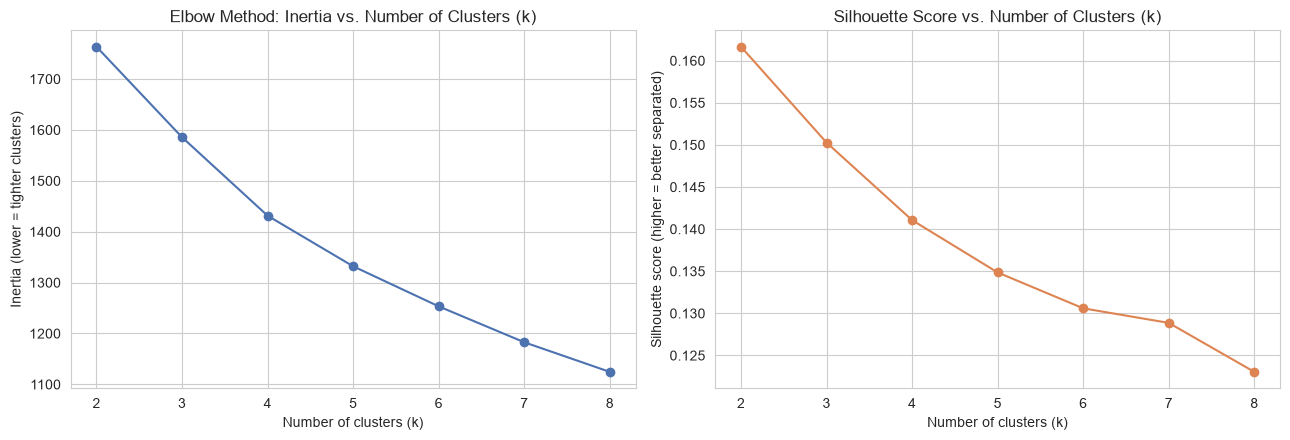

k=2: silhouette score = 0.162
k=3: silhouette score = 0.150
k=4: silhouette score = 0.141
k=5: silhouette score = 0.135
k=6: silhouette score = 0.131
k=7: silhouette score = 0.129
k=8: silhouette score = 0.123


In [ ]:
inertia_values = []
silhouette_values = []
k_range = range(2, 9)   # test k = 2 through 8 segments

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)   # n_init=10 -> tries 10 random starting points, keeps the best
    labels = km.fit_predict(cluster_input_df)
    inertia_values.append(km.inertia_)                       # how tight the clusters are (lower = tighter)
    silhouette_values.append(silhouette_score(cluster_input_df, labels))  # how well-separated (higher = better)

# --- Plot the Elbow curve ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(list(k_range), inertia_values, marker="o", color="#4C72B0")
axes[0].set_title("Elbow Method: Inertia vs. Number of Clusters (k)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (lower = tighter clusters)")

axes[1].plot(list(k_range), silhouette_values, marker="o", color="#DD8452")
axes[1].set_title("Silhouette Score vs. Number of Clusters (k)")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score (higher = better separated)")

plt.tight_layout()
# Save the figure in HD
#plt.savefig("silhouette score.png", dpi=300, bbox_inches="tight")
plt.show()

for k, sil in zip(k_range, silhouette_values):
    print(f"k={k}: silhouette score = {sil:.3f}")


**How to read this:**
- Look at the **left chart** for the "elbow" — the k value where the line stops dropping sharply and starts flattening.
- Look at the **right chart** for the k with the **highest bar/point** — that's the statistically best-separated segmentation.
- In practice, we also apply business judgement: a `k` that is statistically great but produces 1 tiny cluster + 1 huge cluster is less useful than a slightly-less-perfect `k` that produces evenly usable segments.

👉 **For this notebook, we'll proceed with `k = 4`** (a common, business-interpretable choice — e.g., "Casual Browsers", "Budget Learners", "Premium Upskillers", "At-Risk/Dormant"). **Change `optimal_k` below to whatever your Elbow/Silhouette results suggest for your real data.**


In [12]:
optimal_k = 4   # <-- change this based on YOUR elbow/silhouette plots
print(f"Selected number of learner segments: k = {optimal_k}")


Selected number of learner segments: k = 4


## Step 7 — Fit the Final K-Means Model

Now that we've picked `k`, we train the final K-Means model on the full learner dataset and attach a `Cluster` label to every learner.

- **`KMeans(n_clusters=optimal_k, random_state=42, n_init=10)`** creates the model. `random_state=42` just makes results reproducible (same answer every time we re-run).
- **`.fit_predict(...)`** does two things at once: (1) finds the cluster centres, (2) assigns every learner to their nearest cluster centre.


In [13]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
learner_df["Cluster"] = kmeans_final.fit_predict(cluster_input_df)

print("Learners per segment:")
print(learner_df["Cluster"].value_counts().sort_index())

display(learner_df.head())


Learners per segment:
Cluster
0     85
1     81
2    100
3     32
Name: count, dtype: int64


,UserID,TotalCourses,TotalSpend,AvgSpend,AvgCourseRating,FavouriteCategory,FavouriteLevel,LastPurchaseDate,Recency,Age,Gender,Cluster
0,U0001,6,15358.70,2559.78,3.52,Business,Advanced,2025-02-23,81,54,Male,2
1,U0002,6,11564.88,1927.48,3.90,Marketing,Advanced,2024-10-14,213,44,Male,3
2,U0003,8,26596.42,3324.55,3.88,Data Science,Advanced,2025-04-04,41,30,Female,0
3,U0004,6,14308.04,2384.67,4.10,Business,Beginner,2025-02-08,96,23,Female,1
4,U0005,8,21642.10,2705.26,3.14,AI/ML,Advanced,2025-04-25,20,36,Female,0


## Step 8 — Hierarchical Clustering (Validating Our Segments)

**Why do this?** K-Means requires us to *choose* `k` upfront, and it can occasionally produce unstable results depending on starting points. **Hierarchical (Agglomerative) Clustering** builds segments differently — it starts by treating every learner as their own tiny cluster and repeatedly merges the two closest clusters until everything is joined into one big tree (a **dendrogram**).

We use this as a **sanity check**: if Hierarchical Clustering, run independently, roughly agrees with K-Means on how many natural groups exist and which learners belong together, we can be more confident our segments are genuine patterns — not a fluke of one algorithm.

### 8.1 — Draw the dendrogram
- `linkage(data, method="ward")` calculates the merge order. `"ward"` minimises the variance within each merged cluster (works well with scaled numeric data, same idea as K-Means).
- `dendrogram(...)` visualises this as an upside-down tree. Reading it: the **height** at which two branches join represents how "different" those groups are. **Long vertical lines you can "cut" horizontally** suggest a natural number of clusters.


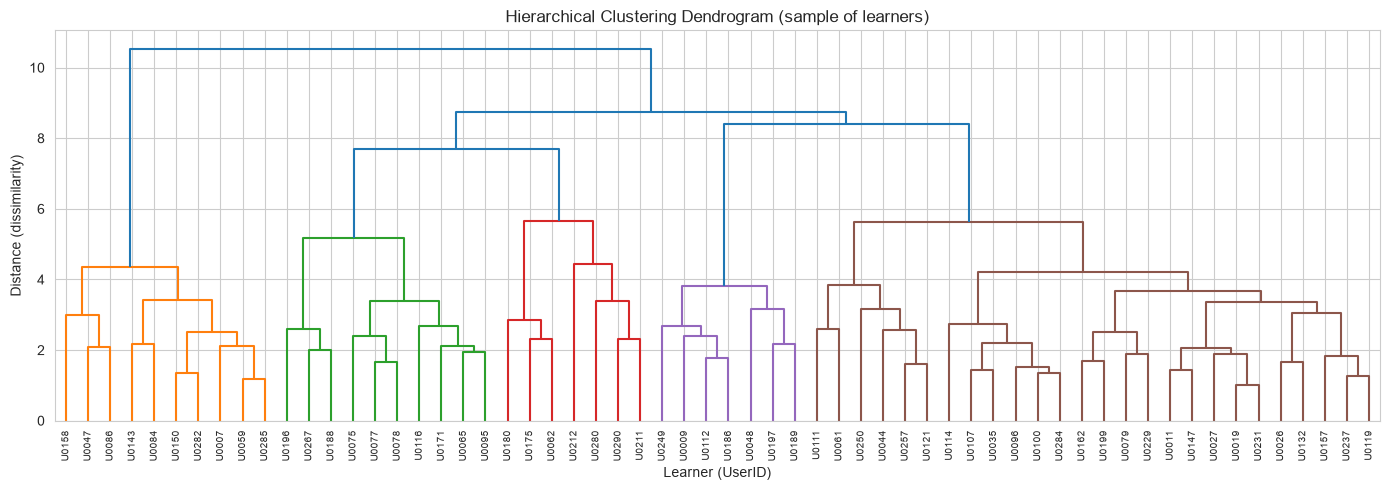

In [14]:
# For speed/readability on the dendrogram, we sample up to 60 learners if the dataset is large
sample_size = min(60, len(cluster_input_df))
sample_idx = cluster_input_df.sample(sample_size, random_state=42).index

linkage_matrix = linkage(cluster_input_df.loc[sample_idx], method="ward")

plt.figure(figsize=(14, 5))
dendrogram(linkage_matrix, labels=learner_df.loc[sample_idx, "UserID"].values, leaf_rotation=90, leaf_font_size=7)
plt.title("Hierarchical Clustering Dendrogram (sample of learners)")
plt.xlabel("Learner (UserID)")
plt.ylabel("Distance (dissimilarity)")
plt.tight_layout()
plt.show()


### 8.2 — Fit Agglomerative Clustering with the same `k` and compare to K-Means

We now run `AgglomerativeClustering` with the **same number of clusters** we chose for K-Means, and check how much the two methods **agree** using a cross-tabulation (a simple confusion-matrix-style table).


In [15]:
agglo = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
learner_df["Cluster_Hierarchical"] = agglo.fit_predict(cluster_input_df)

# Cross-tab: rows = K-Means clusters, columns = Hierarchical clusters
comparison_table = pd.crosstab(learner_df["Cluster"], learner_df["Cluster_Hierarchical"])
print("Agreement between K-Means and Hierarchical Clustering:")
display(comparison_table)


Agreement between K-Means and Hierarchical Clustering:


Cluster_Hierarchical,0,1,2,3
Cluster,,,,
0,1,31,53,0
1,69,5,5,2
2,14,85,1,0
3,6,2,0,24


**How to read this table:** if most learners in each K-Means row are concentrated in a single Hierarchical column (rather than spread evenly across columns), the two independent methods largely **agree** — which validates that our learner segments reflect real, stable patterns rather than random noise. We will use the **K-Means labels (`Cluster`)** going forward for the recommendation engine, since K-Means scales better to large, growing datasets like EduPro's live user base.


## Step 9 — Profile Each Segment (Turning Numbers into Business Personas)

A cluster labelled "2" means nothing to a marketing manager. Here we describe **what each cluster actually looks like** in plain business terms, using the *original* (unscaled) values so they're easy to interpret.

- `.groupby("Cluster").mean()` gives us the **average profile** of each segment for every numeric column.
- We also find each cluster's most common favourite category/level using our `most_common` helper.


In [16]:
profile_numeric = learner_df.groupby("Cluster")[["Age","TotalCourses","TotalSpend","AvgSpend","AvgCourseRating","Recency"]].mean().round(1)

profile_categorical = learner_df.groupby("Cluster").agg(
    TopCategory = ("FavouriteCategory", most_common),
    TopLevel    = ("FavouriteLevel", most_common),
    ClusterSize = ("UserID", "count")
)

cluster_profile = profile_numeric.join(profile_categorical)
display(cluster_profile)


,Age,TotalCourses,TotalSpend,AvgSpend,AvgCourseRating,Recency,TopCategory,TopLevel,ClusterSize
Cluster,,,,,,,,,
0,34.2,9.1,24796.3,2726.2,3.8,46.8,Business,Advanced,85
1,24.1,4.7,11855.9,2604.7,3.7,78.4,AI/ML,Advanced,81
2,45.8,5.4,14680.8,2737.3,3.8,63.2,AI/ML,Advanced,100
3,39.2,3.1,6183.9,2072.7,3.8,239.9,AI/ML,Advanced,32


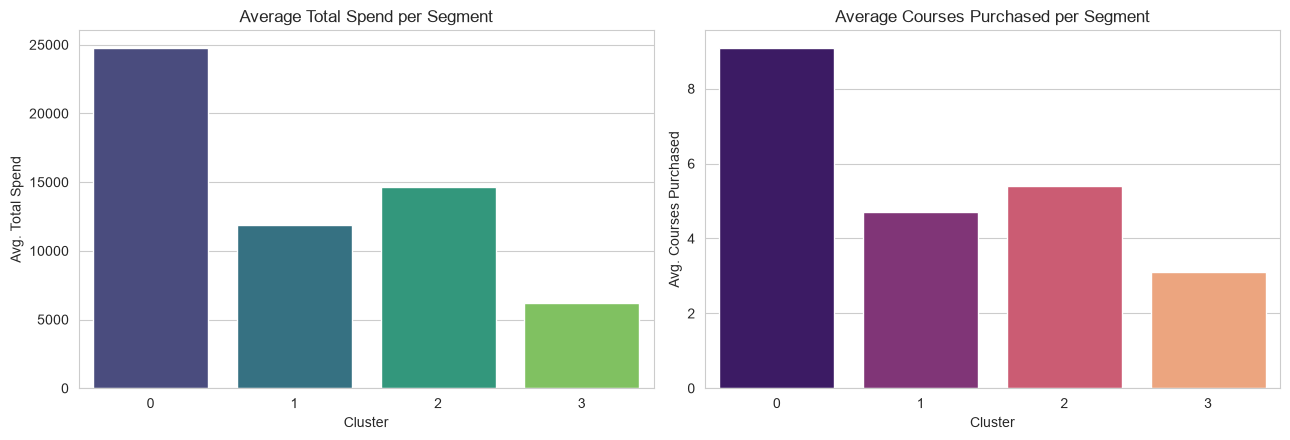

In [ ]:
# Visualise average spend and course count per cluster - easy for stakeholders to read at a glance
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(x=cluster_profile.index, y=cluster_profile["TotalSpend"], ax=axes[0], palette="viridis")
axes[0].set_title("Average Total Spend per Segment")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Avg. Total Spend")

sns.barplot(x=cluster_profile.index, y=cluster_profile["TotalCourses"], ax=axes[1], palette="magma")
axes[1].set_title("Average Courses Purchased per Segment")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Avg. Courses Purchased")

plt.tight_layout()
# Save the figure in HD
#plt.savefig("average spend and course count per cluster.png", dpi=300, bbox_inches="tight")
plt.show()


### 📊 Turning this into business personas

Look at the `cluster_profile` table above and assign a **business-friendly name** to each cluster, e.g.:

- **High spend + many courses + low recency** → *"Premium Power Learners"* → target with advanced/premium course upsells.
- **Low spend + few courses + high recency (long time since last purchase)** → *"At-Risk / Dormant Learners"* → target with win-back discounts or beginner content.
- **Moderate spend + strong preference for one category** → *"Focused Specialists"* → target with deep, category-specific course tracks.
- **Young age + Beginner level preference** → *"New Explorers"* → target with onboarding journeys and foundational courses.

*(Replace these example labels with names that match what you actually observe in `cluster_profile` for your real EduPro data.)*


## Step 10 — Personalised, Cluster-Aware Recommendation Engine

Now for the core business deliverable: **recommend courses to each learner**, using **four combined signals**, exactly as specified in the methodology:

1. **Content-based filtering** — recommend courses *similar in nature* (category/type/level) to what the learner already bought.
2. **Similar learner profiles** — recommend courses that *learners in the same cluster* commonly buy (collaborative-style signal, but cluster-based instead of learner-by-learner, which scales much better).
3. **Course popularity within cluster** — favour courses that are broadly popular among the learner's segment (safe, proven choices).
4. **Rating-weighted release** — among candidate courses, boost ones with a higher `CourseRating` (quality-first).

### 10.1 — Content-based similarity between courses

We convert each course's category/type/level into one-hot vectors, then use **cosine similarity** to measure how "alike" any two courses are (1 = identical profile, 0 = nothing in common).


In [18]:
# One-hot encode course attributes to describe each course as a vector of 0s/1s
course_features = pd.get_dummies(
    courses_df[["CourseCategory", "CourseType", "Course Level"]], drop_first=False
)
course_features.index = courses_df["CourseID"]

# Cosine similarity: for every pair of courses, how similar are their attribute vectors?
course_similarity = cosine_similarity(course_features)
course_similarity_df = pd.DataFrame(course_similarity, index=course_features.index, columns=course_features.index)

display(course_similarity_df.iloc[:5, :5])   # preview a small corner of the similarity matrix


CourseID,C001,C002,C003,C004,C005
CourseID,,,,,
C001,1.000000,0.333333,0.000000,0.333333,0.333333
C002,0.333333,1.000000,0.666667,0.333333,0.666667
C003,0.000000,0.666667,1.000000,0.000000,0.333333
C004,0.333333,0.333333,0.000000,1.000000,0.333333
C005,0.333333,0.666667,0.333333,0.333333,1.000000


**How to read this matrix:** `course_similarity_df.loc["C001", "C002"]` tells you how similar course `C001` and `C002` are (0 to 1). We'll use each row to find "courses like this one".


### 10.2 — Cluster-level course popularity (with rating-weighting)

For every cluster, we calculate how popular each course is **within that cluster** (how many learners in that segment bought it), then blend in the course's own rating so that popular-**and**-well-rated courses rank highest.

`PopularityScore = (times bought within cluster) × (CourseRating / 5)`

This is a simple, explainable way to satisfy the "rating-weighted release" requirement — courses with more buyers get a higher base score, but a low rating drags the score down, and a high rating boosts it.


In [19]:
# Attach each transaction's cluster (via the buyer's UserID) so we can count purchases per cluster
merged_with_cluster = merged_df.merge(learner_df[["UserID", "Cluster"]], on="UserID", how="left")

# Count how many times each course was purchased within each cluster
cluster_course_counts = (
    merged_with_cluster.groupby(["Cluster", "CourseID"])
    .size()
    .reset_index(name="TimesBoughtInCluster")
)

# Bring in the course rating
cluster_course_counts = cluster_course_counts.merge(
    courses_df[["CourseID", "CourseRating", "CourseCategory", "Course Level", "CourseType"]],
    on="CourseID", how="left"
)

# Rating-weighted popularity score
cluster_course_counts["PopularityScore"] = (
    cluster_course_counts["TimesBoughtInCluster"] * (cluster_course_counts["CourseRating"] / 5)
).round(3)

display(cluster_course_counts.sort_values(["Cluster", "PopularityScore"], ascending=[True, False]).head(10))


,Cluster,CourseID,TimesBoughtInCluster,CourseRating,CourseCategory,Course Level,CourseType,PopularityScore
27,0,C028,19,4.9,Marketing,Beginner,Video,18.62
16,0,C017,18,4.8,AI/ML,Intermediate,Text-based,17.28
21,0,C022,18,4.6,Web Development,Advanced,Live Cohort,16.56
53,0,C054,17,4.6,Business,Intermediate,Video,15.64
36,0,C037,16,4.8,Finance,Beginner,Text-based,15.36
12,0,C013,18,4.2,Finance,Intermediate,Video,15.12
54,0,C055,17,4.4,Web Development,Intermediate,Text-based,14.96
56,0,C057,15,4.8,Finance,Advanced,Text-based,14.40
44,0,C045,17,4.2,Web Development,Intermediate,Live Cohort,14.28
28,0,C029,16,4.3,AI/ML,Beginner,Video,13.76


### 10.3 — Putting it all together: the `recommend_courses()` function

This function generates the final personalised course list for any given learner by combining all four signals:

1. Look up the learner's **cluster**.
2. Find the courses that are **popular (rating-weighted) within that cluster**.
3. Find courses **content-similar** to what the learner has already bought.
4. **Exclude courses the learner already owns.**
5. Blend both scores and return the **top N** recommendations.


In [20]:
def recommend_courses(user_id, top_n=5, content_weight=0.5, popularity_weight=0.5):
    '''
    Recommend courses for a given learner using cluster-aware, content-based,
    rating-weighted logic.

    Parameters
    ----------
    user_id : str          -> the learner's UserID
    top_n : int             -> how many courses to recommend
    content_weight : float  -> importance given to "similar to what they already bought"
    popularity_weight : float -> importance given to "popular & well-rated within their segment"
    '''
    # 1. Find this learner's cluster
    if user_id not in learner_df["UserID"].values:
        return f"UserID {user_id} not found."
    learner_cluster = learner_df.loc[learner_df["UserID"] == user_id, "Cluster"].values[0]

    # 2. Courses this learner has already purchased (to exclude from recommendations)
    already_bought = merged_df.loc[merged_df["UserID"] == user_id, "CourseID"].unique().tolist()

    # 3. Cluster popularity score for every candidate course (rating-weighted)
    cluster_scores = cluster_course_counts[cluster_course_counts["Cluster"] == learner_cluster].copy()
    cluster_scores = cluster_scores.set_index("CourseID")["PopularityScore"]

    # 4. Content-based score: average similarity to the courses the learner already bought
    if len(already_bought) > 0:
        sim_scores = course_similarity_df[already_bought].mean(axis=1)
    else:
        sim_scores = pd.Series(0, index=course_similarity_df.index)

    # 5. Combine into one candidate table (align on CourseID, fill missing with 0)
    candidates = pd.DataFrame({
        "PopularityScore": cluster_scores,
        "ContentSimilarity": sim_scores
    }).fillna(0)

    # Normalise each score column to 0-1 range so weights are meaningful
    for col in ["PopularityScore", "ContentSimilarity"]:
        max_val = candidates[col].max()
        candidates[col] = candidates[col] / max_val if max_val > 0 else 0

    # 6. Final blended score
    candidates["FinalScore"] = (
        popularity_weight * candidates["PopularityScore"] +
        content_weight * candidates["ContentSimilarity"]
    )

    # 7. Remove courses already purchased
    candidates = candidates.drop(index=[c for c in already_bought if c in candidates.index], errors="ignore")

    # 8. Attach readable course info and return the top N
    result = candidates.merge(courses_df, left_index=True, right_on="CourseID")
    result = result.sort_values("FinalScore", ascending=False).head(top_n)

    return result[["CourseID", "CourseCategory", "Course Level", "CourseType", "CourseRating", "FinalScore"]]


print("✅ recommend_courses() is ready to use.")


✅ recommend_courses() is ready to use.


### 10.4 — Try it out

Let's generate recommendations for a sample learner and see the result. In production, EduPro would call `recommend_courses(user_id)` every time that learner logs in or views the course catalogue.


In [21]:
sample_user = learner_df["UserID"].iloc[0]
print(f"Generating recommendations for learner: {sample_user} "
      f"(Cluster {learner_df.loc[learner_df['UserID']==sample_user, 'Cluster'].values[0]})\n")

recommend_courses(sample_user, top_n=5)


Generating recommendations for learner: U0001 (Cluster 2)



,CourseID,CourseCategory,Course Level,CourseType,CourseRating,FinalScore
0,C001,Business,Advanced,Text-based,4.8,0.961538
51,C052,Web Development,Beginner,Video,4.5,0.825893
22,C023,Web Development,Beginner,Video,4.3,0.805060
48,C049,Design,Advanced,Video,2.8,0.791667
50,C051,Business,Beginner,Video,4.0,0.788462


## Step 11 — Business Summary & Next Steps

### ✅ What we achieved
- Turned raw transaction logs into **learner-level profiles** combining demographics + behaviour.
- Statistically justified the number of learner segments using **Elbow** and **Silhouette** methods.
- Built and **validated** learner segments with two independent algorithms (**K-Means** + **Hierarchical Clustering**).
- Converted abstract clusters into **business personas** EduPro's marketing and content teams can act on.
- Built a **personalised recommendation engine** that blends content similarity, cluster-level popularity, and course rating — replacing the old one-size-fits-all approach.

### 📈 Suggested Business Actions
- **Marketing:** run cluster-specific email/push campaigns (e.g., win-back offers for "At-Risk" learners, premium upsells for "Power Learners").
- **Content strategy:** commission more courses in categories that are popular in high-value clusters but currently under-supplied.
- **Product:** surface `recommend_courses(user_id)` output directly on the homepage and "next course" prompts after checkout.
- **Monitoring:** re-run this notebook periodically (e.g., monthly) as new transactions come in, since learner behaviour — and therefore segments — will evolve.

### 🔜 Possible Next Steps
- Add **enrolment completion / drop-off data** if available, to segment by engagement quality, not just spend.
- Experiment with alternative clustering algorithms (e.g., DBSCAN) if segments are irregularly shaped.
- A/B test the recommendation engine against the current system to measure lift in click-through and purchase rate.
